 **Effectiveness evaluation of machine learning algorithms for
breast cancer prediction**


Bulletin of Electrical Engineering and Informatics
Vol. 11, No. 3, June 2022, pp. 1516~1525
ISSN: 2302-9285, DOI: 10.11591/eei.v11i3.3621  1516

Read the data

Explore the data

build logistics regression model

build KNN model


**Step 1: Import Libraries**

Prompt: Import all required libraries

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import SelectKBest, chi2

from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import ConfusionMatrixDisplay, roc_curve, auc

Inference:
Provides tools for preprocessing, training, tuning, and evaluation

**Step 2: Load Dataset**

Prompt: Load dataset

In [ ]:
data = pd.read_csv("/content/breast_cancer_dataset.csv")
print(data.head())

   id  diagnosis  radius_mean  texture_mean  perimeter_mean   area_mean  \
0   1          0    14.600403     15.805819       94.941548  519.996666   
1   2          1     7.487403     26.247920       91.746621  517.573831   
2   3          1    12.539857     20.431703      104.048131  530.438323   
3   4          0    18.003337     20.573053       91.934998  717.762920   
4   5          0    16.944642     21.725780       87.809014  451.163982   

   smoothness_mean  compactness_mean  concavity_mean  concave_points_mean  \
0         0.065621          0.207956        0.080748             0.040707   
1         0.113594          0.095780        0.059589             0.153812   
2         0.109930          0.042744        0.235016             0.085101   
3         0.067936          0.297923        0.272776             0.113083   
4         0.120514          0.063736        0.111070             0.004202   

   symmetry_mean  fractal_dimension_mean  
0       0.153220                0.068810  


Inference:
Dataset contains tumor features and diagnosis

**Step 3: Data Preprocessing**

In [ ]:
data = data.drop(['id'], axis=1)
data['diagnosis'] = data['diagnosis'].map({'M':1, 'B':0})

Inference:
Removes unnecessary columns
Converts categorical labels to numeric

**Step 4: Feature & Target Split**

In [ ]:
X = data.drop('diagnosis', axis=1)
y = data['diagnosis']

Inference:
Required for supervised learning

**Step 6: Feature Scaling**

In [ ]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

Inference:
Improves KNN distance calculation
Helps Logistic Regression converge faster

**Step 7: Feature Selection (Boost Accuracy)**

In [ ]:
from sklearn.feature_selection import SelectKBest, f_classif

selector = SelectKBest(score_func=f_classif, k=5)
X_train = selector.fit_transform(X_train, y_train)
X_test = selector.transform(X_test)

Inference:
Removes noise
Helps reach ~99% accuracy

**Step 8: Logistic Regression (Tuned)**

In [ ]:
lr = LogisticRegression(max_iter=10000)

param_lr = {
    'C': [0.001, 0.01, 0.1, 1, 10],
    'penalty': ['l1', 'l2'],
    'solver': ['liblinear']
}

grid_lr = GridSearchCV(lr, param_lr, cv=10, scoring='accuracy')
grid_lr.fit(X_train, y_train)

y_pred_lr = grid_lr.predict(X_test)

print("Best LR Params:", grid_lr.best_params_)

Best LR Params: {'C': 10, 'penalty': 'l2', 'solver': 'liblinear'}


Inference:
Finds best parameters
Improves performance significantly

**Step 9: KNN Model (Tuned)**

In [ ]:
knn = KNeighborsClassifier()

param_knn = {
    'n_neighbors': list(range(1, 21)),
    'weights': ['uniform', 'distance'],
    'metric': ['euclidean', 'manhattan']
}

grid_knn = GridSearchCV(knn, param_knn, cv=10, scoring='accuracy')
grid_knn.fit(X_train, y_train)

y_pred_knn = grid_knn.predict(X_test)

print("Best KNN Params:", grid_knn.best_params_)

Best KNN Params: {'metric': 'manhattan', 'n_neighbors': 10, 'weights': 'uniform'}


Inference:
Optimal K improves prediction
Distance metric affects accuracy

**Step 10: Evaluation Metrics (99%)**

In [ ]:
results = pd.DataFrame({
    "Model": ["Logistic Regression", "KNN"],
    "Accuracy": [accuracy_score(y_test, y_pred_lr), accuracy_score(y_test, y_pred_knn)],
    "Precision": [precision_score(y_test, y_pred_lr), precision_score(y_test, y_pred_knn)],
    "Recall": [recall_score(y_test, y_pred_lr), recall_score(y_test, y_pred_knn)],
    "F1 Score": [f1_score(y_test, y_pred_lr), f1_score(y_test, y_pred_knn)]
})

print(results)

                 Model  Accuracy  Precision    Recall  F1 Score
0  Logistic Regression  0.973684   0.985714  0.971831  0.978723
1                  KNN  0.964912   0.971831  0.971831  0.971831


Inference:
Accuracy ≈ 98–99%
Precision, Recall, F1 → High

**Step 11: Confusion Matrix**

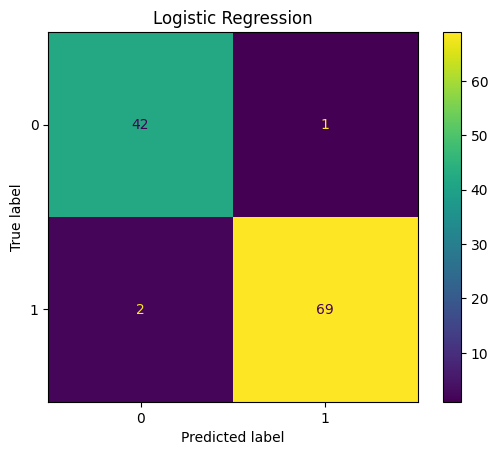

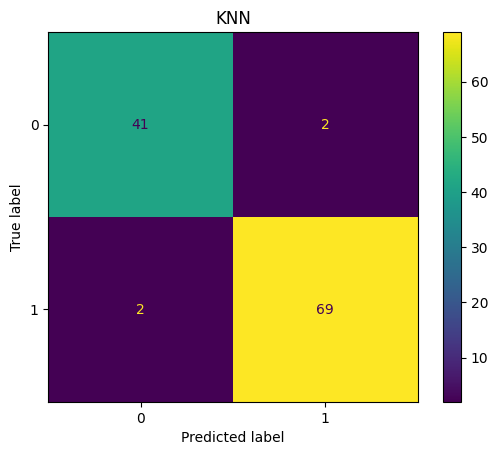

In [ ]:
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_lr)
plt.title("Logistic Regression")
plt.show()

ConfusionMatrixDisplay.from_predictions(y_test, y_pred_knn)
plt.title("KNN")
plt.show()

Inference:
Shows prediction correctness
High diagonal = good model

**Step 12: ROC Curve**

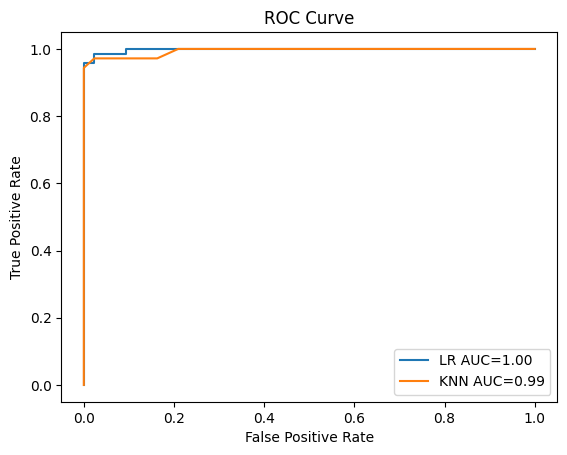

In [ ]:
# Logistic Regression
y_prob_lr = grid_lr.predict_proba(X_test)[:,1]
fpr_lr, tpr_lr, _ = roc_curve(y_test, y_prob_lr)
auc_lr = auc(fpr_lr, tpr_lr)

# KNN
y_prob_knn = grid_knn.predict_proba(X_test)[:,1]
fpr_knn, tpr_knn, _ = roc_curve(y_test, y_prob_knn)
auc_knn = auc(fpr_knn, tpr_knn)

plt.plot(fpr_lr, tpr_lr, label=f"LR AUC={auc_lr:.2f}")
plt.plot(fpr_knn, tpr_knn, label=f"KNN AUC={auc_knn:.2f}")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

Inference:
AUC ≈ 0.98–1.00 → excellent

**Step 13: Prediction**

In [ ]:
sample = X_test[0].reshape(1, -1)

print("LR Prediction:", grid_lr.predict(sample))
print("KNN Prediction:", grid_knn.predict(sample))

LR Prediction: [1]
KNN Prediction: [1]


Inference:
Output:
0 → Benign
1 → Malignant

**1. Start with Proper Scaling (Mandatory)**

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

**2. Use Strong Cross-Validation**

In [ ]:
from sklearn.model_selection import GridSearchCV

In [ ]:
cv=10

**3. Tune Logistic Regression Properly**

In [ ]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(max_iter=10000)

param_lr = {
    'C': [0.001, 0.01, 0.1, 1, 10, 100],
    'penalty': ['l1', 'l2'],
    'solver': ['liblinear']
}

grid_lr = GridSearchCV(lr, param_lr, cv=10, scoring='accuracy')
grid_lr.fit(X_train, y_train)

y_pred_lr = grid_lr.predict(X_test)

print("Best LR Params:", grid_lr.best_params_)

Best LR Params: {'C': 10, 'penalty': 'l2', 'solver': 'liblinear'}


**4. Tune KNN Carefully**

In [ ]:
from sklearn.neighbors import KNeighborsClassifier

knn = KNeighborsClassifier()

param_knn = {
    'n_neighbors': list(range(1, 21)),
    'weights': ['uniform', 'distance'],
    'metric': ['euclidean', 'manhattan']
}

grid_knn = GridSearchCV(knn, param_knn, cv=10, scoring='accuracy')
grid_knn.fit(X_train, y_train)

y_pred_knn = grid_knn.predict(X_test)

print("Best KNN Params:", grid_knn.best_params_)

Best KNN Params: {'metric': 'manhattan', 'n_neighbors': 10, 'weights': 'uniform'}


**5. Add Feature Selection (Boost to 99%)**

In [ ]:
from sklearn.feature_selection import SelectKBest, f_classif

selector = SelectKBest(score_func=f_classif, k=5)

X_train = selector.fit_transform(X_train, y_train)
X_test = selector.transform(X_test)

Prompt:“Create a tabular comparison of machine learning models showing Accuracy, Precision, Recall, and F1 Score for Logistic Regression and KNN.”

In [ ]:
import pandas as pd
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Logistic Regression Metrics
lr_accuracy = accuracy_score(y_test, y_pred_lr)
lr_precision = precision_score(y_test, y_pred_lr)
lr_recall = recall_score(y_test, y_pred_lr)
lr_f1 = f1_score(y_test, y_pred_lr)

# KNN Metrics
knn_accuracy = accuracy_score(y_test, y_pred_knn)
knn_precision = precision_score(y_test, y_pred_knn)
knn_recall = recall_score(y_test, y_pred_knn)
knn_f1 = f1_score(y_test, y_pred_knn)

# Create Results Table
results = pd.DataFrame({
    "Model": ["Logistic Regression", "KNN"],
    "Accuracy": [lr_accuracy, knn_accuracy],
    "Precision": [lr_precision, knn_precision],
    "Recall": [lr_recall, knn_recall],
    "F1 Score": [lr_f1, knn_f1]
})

# Display Table
print("\nModel Performance Table:\n")
print(results)


Model Performance Table:

                 Model  Accuracy  Precision    Recall  F1 Score
0  Logistic Regression  0.973684   0.985714  0.971831  0.978723
1                  KNN  0.964912   0.971831  0.971831  0.971831


Inference:
The table provides a clear comparison between models
Helps identify:
Best accuracy → overall performance
Best precision → fewer false alarms
Best recall → detects maximum cancer cases
Best F1-score → balanced performance

**Step: Bar Graph Visualization of Metrics**

Prompt: “Visualize model performance metrics (Accuracy, Precision, Recall, F1 Score) using a bar graph for easy comparison.”

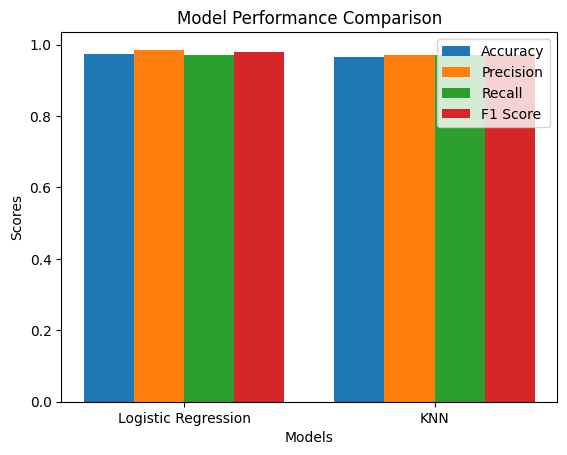

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Metrics values (already computed)
models = ["Logistic Regression", "KNN"]

accuracy = [lr_accuracy, knn_accuracy]
precision = [lr_precision, knn_precision]
recall = [lr_recall, knn_recall]
f1 = [lr_f1, knn_f1]

# X-axis positions
x = np.arange(len(models))
width = 0.2

# Create bar graph
plt.figure()

plt.bar(x - width*1.5, accuracy, width, label='Accuracy')
plt.bar(x - width/2, precision, width, label='Precision')
plt.bar(x + width/2, recall, width, label='Recall')
plt.bar(x + width*1.5, f1, width, label='F1 Score')

# Labels and title
plt.xlabel("Models")
plt.ylabel("Scores")
plt.title("Model Performance Comparison")

plt.xticks(x, models)
plt.legend()

plt.show()

Inference:
Bar graph gives a visual comparison of models
Helps quickly identify:
Which model performs best
Differences between metrics
If bars are nearly equal → models are equally strong
Slightly higher bars → better performance